# Line detection
This Jupyter Notebook show how we can detect a line using Hough Transformation

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load data

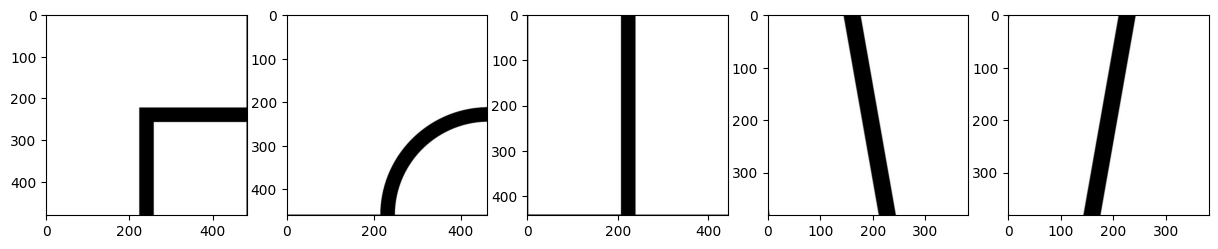

In [13]:
plt.figure(figsize=(15,6))

plt.subplot(1, 5, 1)
plt.imshow(cv2.imread('datas/ladrinho1.jpg'));
plt.subplot(1, 5, 2)
plt.imshow(cv2.imread('datas/ladrinho2.jpg'));
plt.subplot(1, 5, 3)
plt.imshow(cv2.imread('datas/ladrinho3_reto.jpg'));
plt.subplot(1, 5, 4)
plt.imshow(cv2.imread('datas/ladrinho3_esquerda.jpg'));
plt.subplot(1, 5, 5)
plt.imshow(cv2.imread('datas/ladrinho3_direita.jpg'));

## Detecting the line

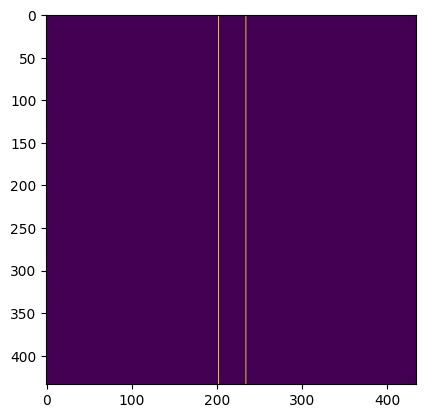

In [51]:
img = cv2.imread('datas/ladrinho3_reto.jpg')
img_reserve = img.copy()
# Convert the image to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# fint the edges in the image
edges = cv2.Canny(img_gray, 50, 200)
plt.imshow(edges);

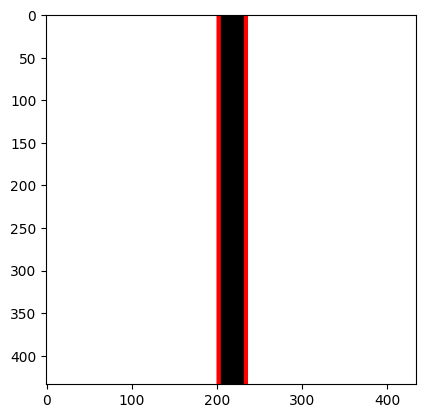

In [106]:
# Detect points that form a line
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 70, minLineLength=15, maxLineGap=250)

# Draw lines on the image
for line in lines:
   x1, y1, x2, y2 = line[0]
   cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
# Show result
plt.imshow(img);

We got detect the line, but we need create a imagination line to make the measure of the car

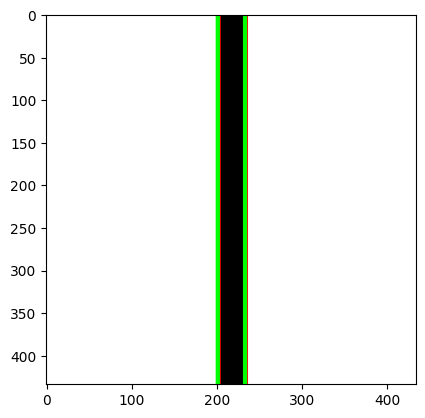

In [107]:
# determine the size of the line
line_thickness = 32

# extract the img size
x, y, _ = img.shape

# determine the position of car flow line in relation of x label
car_flow_x = int((x - line_thickness) / 2)
start_point = (car_flow_x, 0)
end_point = (car_flow_x, y)

thickness = 3
color=(0, 255, 0)
# drawn the line 1
line_flow_1 = cv2.line(img, start_point, end_point, color, thickness)

start_point = (car_flow_x + line_thickness, 0)
end_point = (car_flow_x + line_thickness, y)
# drawn the line 2
line_flow_2 = cv2.line(img, start_point, end_point, color, thickness)

plt.imshow(img);

# We got drawn the flow car line 
now we've to measure the diff into the path correct(red) and the flow path(green)

In [108]:
# get the correct path
target_line1 = lines[0]
target_line2 = lines[1]

# extract the point x of target_line
start_point_target = target_line1[0][:2][0]
end_point_target = target_line2[0][:2][0]

start_point_target, end_point_target

(202, 234)

In [109]:
# extract the point x of flow_car
start_point_flow = car_flow_x
end_point_flow = start_point_flow + line_thickness

start_point_flow, end_point_flow

(201, 233)

In [110]:
# calculate the diff = error
error_left = np.abs(start_point_target - start_point_flow)
error_right = np.abs(end_point_target - end_point_flow)

error_left, error_right

(1, 1)

Wow, we got made the measure of target line and car flow. What's happen now?

- We need make a algoritm to adjust the motor speed to fix the carr in target line, but before let's try with another images.

Do you mind. I need do rewrite all code again. A: no, let's make a function!

In [55]:
def calculate_error(target_line, flow_line):
    """
    Calculates the error between the target line position and the car flow line position.

    Args:
        target_line (list): List containing the coordinates of the detected target line.
        start_point_flow (int): X-axis starting position of the car flow line.

    Returns:
        tuple: A tuple (error_left, error_right), representing the error with respect 
               to the left and right edges of the target line.
    """
    # extract the target line
    start_point_target = target_line[0][0][:2][0]
    end_point_target = target_line[1][0][:2][0]

    # extract the car flow
    start_point_flow = flow_line[0]
    end_point_flow = flow_line[1]

    # to debug
    print('Target (x1, x2): ', str(start_point_target), str(end_point_target))
    print('Flow (x1, x2): ', str(start_point_flow), str(end_point_flow))
    # calculate the error
    error_left = np.abs(start_point_target - start_point_flow)
    error_right = np.abs(end_point_target - end_point_flow)

    #return the erro in format (left, right)
    return (error_left, error_right)

In [154]:
def draw_line(img):
    """
    Draws two vertical lines on the image representing the car flow boundaries.

    Args:
        img (numpy.ndarray): The input image on which the lines will be drawn.

    Returns:
        tuple: A tuple (left, right) representing the X-coordinates of the left and right 
               boundaries of the car flow line.
    """
    # determine the size of the line
    line_thickness = 32
    
    # extract the img size
    y, x, _ = img.shape
    
    # determine the position of car flow line in relation of x label
    car_flow_x = int((x - line_thickness) / 2)
    start_point1 = (car_flow_x, 0)
    end_point1 = (car_flow_x, y)
    
    thickness = 3
    color=(0, 255, 0)
    # drawn the line 1
    line_flow_1 = cv2.line(img, start_point1, end_point1, color, thickness)
    
    start_point2 = (car_flow_x + line_thickness, 0)
    end_point2 = (car_flow_x + line_thickness, y)
    # drawn the line 2
    line_flow_2 = cv2.line(img, start_point2, end_point2, color, thickness)

    # return the position in format (left, right)
    return (car_flow_x, car_flow_x+line_thickness)

In [155]:
def detect_line(img):
    """
    Detects lines in the given image using edge detection and Hough Transform, 
    draws the detected lines, and calculates the error between the detected lines 
    and a reference flow line.

    Args:
        img (numpy.ndarray): Input image, which should be in BGR format.

    Returns:
        float: The calculated error between the detected lines and the flow line.
    
    This function performs the following steps:
        1. Converts the image to grayscale.
        2. Applies the Canny edge detection algorithm to detect edges.
        3. Uses the Hough Transform to detect lines in the image.
        4. Draws the detected lines on the original image.
        5. Draws the reference flow line on the image.
        6. Computes the error between the detected lines and the flow line.
    """
    # Convert the image to grayscale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Aplly a threshold to detect only darken colours
    _, binary = cv2.threshold(img_gray, 50, 255, cv2.THRESH_BINARY_INV)

    # reduce the noise
    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # find the edges on the image
    edges = cv2.Canny(binary, 50, 200)
    
    # Detect points that form a line
    #lines = cv2.HoughLinesP(edges, 1, np.pi/180, 70, minLineLength=20, maxLineGap=255)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # to debug
    #plt.imshow(binary, cmap='gray')  
    #plt.show()

    if contours is not None:
        # Draw lines on the image
        #for line in lines:
        #   x1, y1, x2, y2 = line[0]
        #   cv2.line(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
        cv2.drawContours(img, contours, -1, (255, 0, 0), 2)
        
        #draw the car flow line
        flow_line = draw_line(img)
    
        # calculate the error
        erro = calculate_error(contours, flow_line)
    
        #return erro

None


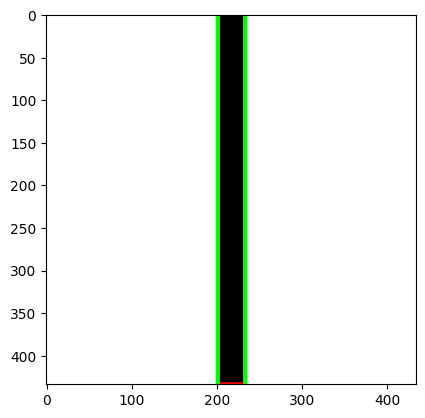

In [156]:
img = cv2.imread('datas/ladrinho3_reto.jpg')
erro = detect_line(img)
plt.imshow(img)
print(erro)

None


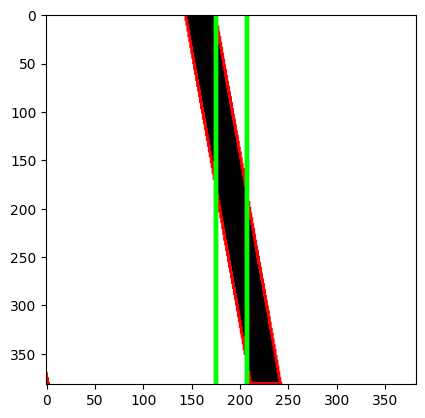

In [150]:
img = cv2.imread('datas/ladrinho3_esquerda.jpg')
erro = detect_line(img)
plt.imshow(img)
print(erro)

None


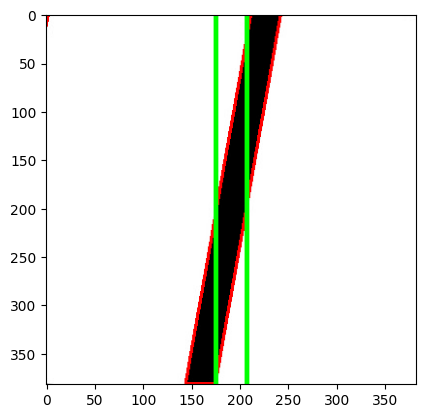

In [151]:
img = cv2.imread('datas/ladrinho3_direita.jpg')
erro = detect_line(img)
plt.imshow(img)
print(erro)

None


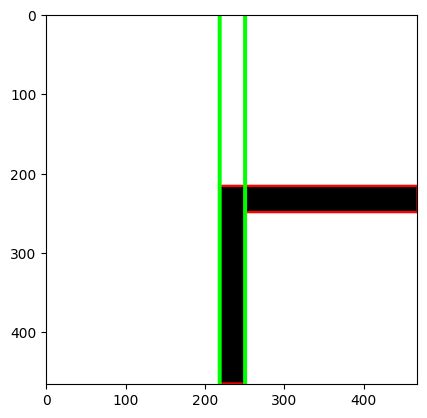

In [152]:
img = cv2.imread('datas/ladrinho1.jpg')
erro = detect_line(img)
plt.imshow(img)
print(erro)

None


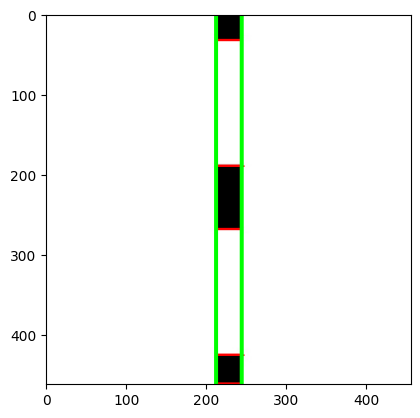

In [153]:
img = cv2.imread('datas/ladrinho5.jpg')
erro = detect_line(img)
plt.imshow(img)
print(erro)

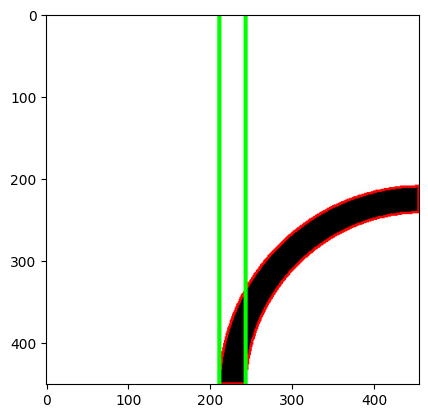

In [148]:
img = cv2.imread('datas/ladrinho2.jpg')
erro = detect_line(img)
plt.imshow(img);